# FHFA HOUSE PRICE PREDICTION INDEX

# Step1:Bussiness Problem
- THE U.S HOUSING MARKET IS INFLUENCED BY ECONOMIC CONDITIONS,INTEREST,RATES AND REGIONAL FACTORRS. PREDICTING FUTURE HOUSE PRICE TRENDS
- DOMAIN:Finance/Real Estate

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step2: Data Loading

In [132]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Projects\\hpi_master.csv")
df

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30
...,...,...,...,...,...,...,...,...,...,...
130692,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,1,201.68,204.83
130693,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,2,224.54,222.68
130694,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,3,233.53,226.83
130695,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,4,229.51,236.17


# Step3:Data Understanding
- yr,period:Time Identifires(Year and month)
- place_name:Region(state,metro,area,division)
- index_nsa:Non-seasonally adjjusted HPI(traget variable)
- index_sa:Seasonally adjusted HPI
- hpi_flavor:Type of index

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130697 entries, 0 to 130696
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   hpi_type    130697 non-null  object 
 1   hpi_flavor  130697 non-null  object 
 2   frequency   130697 non-null  object 
 3   level       130697 non-null  object 
 4   place_name  130697 non-null  object 
 5   place_id    130697 non-null  object 
 6   yr          130697 non-null  int64  
 7   period      130697 non-null  int64  
 8   index_nsa   130697 non-null  float64
 9   index_sa    43429 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 10.0+ MB


In [134]:
df.describe()

,yr,period,index_nsa,index_sa
count,130697.000000,130697.000000,130697.000000,43429.000000
mean,2004.731471,2.619961,186.935563,210.954188
std,12.178554,1.440202,108.376306,105.327102
min,1975.000000,1.000000,18.680000,74.720000
25%,1995.000000,2.000000,110.710000,134.900000
50%,2005.000000,3.000000,164.060000,188.460000
75%,2015.000000,4.000000,225.790000,251.590000
max,2025.000000,12.000000,1268.370000,818.930000


# Step4:Data Exploration

In [135]:
df.isnull().sum()

hpi_type          0
hpi_flavor        0
frequency         0
level             0
place_name        0
place_id          0
yr                0
period            0
index_nsa         0
index_sa      87268
dtype: int64

In [136]:
df['index_sa'].isnull().sum()

np.int64(87268)

- 'index_sa' feature has 87268 missing values

In [137]:
df.duplicated().sum()

np.int64(0)

- There is no duplicated values

In [138]:
df['hpi_type'].unique()

array(['traditional', 'non-metro', 'manufactured', 'distress-free',
       'developmental'], dtype=object)

In [139]:
df['hpi_type'].value_counts()

hpi_type
traditional      122653
non-metro          5687
distress-free      1918
developmental       237
manufactured        202
Name: count, dtype: int64

In [140]:
df['hpi_flavor'].unique()

array(['purchase-only', 'all-transactions', 'expanded-data'], dtype=object)

In [141]:
df['hpi_flavor'].value_counts()

hpi_flavor
all-transactions    87167
purchase-only       28323
expanded-data       15207
Name: count, dtype: int64

In [142]:
df['frequency'].unique()

array(['monthly', 'quarterly'], dtype=object)

In [143]:
df['frequency'].value_counts()

frequency
quarterly    126567
monthly        4130
Name: count, dtype: int64

In [145]:
df['place_name'].value_counts()

place_name
United States                  1090
Middle Atlantic Division        888
East South Central Division     888
Mountain Division               888
East North Central Division     888
                               ... 
Gadsden, AL                     126
Johnstown, PA                   121
Beckley, WV                     113
Hinesville, GA                  103
Wildwood-The Villages, FL        98
Name: count, Length: 472, dtype: int64

In [146]:
df['level'].unique()

array(['USA or Census Division', 'MSA', 'State', 'Puerto Rico'],
      dtype=object)

In [147]:
df['level'].value_counts()

level
MSA                       91466
State                     29912
USA or Census Division     9082
Puerto Rico                 237
Name: count, dtype: int64

In [148]:
df['period'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

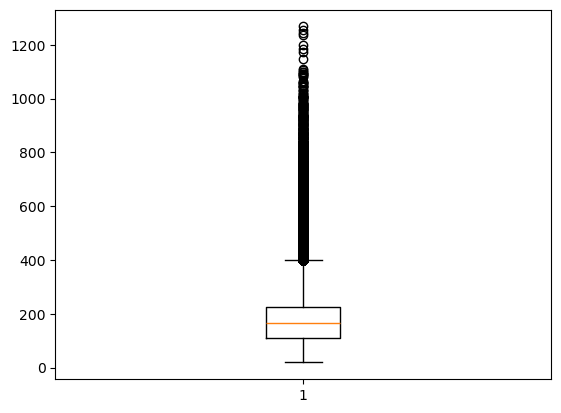

In [149]:
plt.boxplot(df['index_nsa']) 
plt.show()

# Removing Outliers

In [150]:
Q1=df["index_nsa"].quantile(0.25)
print("Q1:",Q1)
Q3=df["index_nsa"].quantile(0.75)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower_limit=Q1-(1.5*IQR)
print("lower_limit",lower_limit)
upper_limit=Q3+(1.5*IQR)
print("upper_limit",upper_limit)

Q1: 110.71
Q3: 225.79
IQR: 115.08
lower_limit -61.91000000000001
upper_limit 398.40999999999997


In [151]:
df[(df["index_nsa"]<lower_limit)|(df["index_nsa"]>upper_limit)]

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
812,traditional,purchase-only,monthly,USA or Census Division,East South Central Division,DV_ESC,2024,4,402.43,397.07
813,traditional,purchase-only,monthly,USA or Census Division,East South Central Division,DV_ESC,2024,5,401.74,396.10
814,traditional,purchase-only,monthly,USA or Census Division,East South Central Division,DV_ESC,2024,6,407.83,399.40
815,traditional,purchase-only,monthly,USA or Census Division,East South Central Division,DV_ESC,2024,7,406.63,399.08
816,traditional,purchase-only,monthly,USA or Census Division,East South Central Division,DV_ESC,2024,8,407.32,402.38
...,...,...,...,...,...,...,...,...,...,...
130318,distress-free,purchase-only,quarterly,MSA,"Tampa, FL (MSAD)",45294,2024,1,555.27,555.54
130319,distress-free,purchase-only,quarterly,MSA,"Tampa, FL (MSAD)",45294,2024,2,573.08,568.22
130320,distress-free,purchase-only,quarterly,MSA,"Tampa, FL (MSAD)",45294,2024,3,562.97,557.10
130321,distress-free,purchase-only,quarterly,MSA,"Tampa, FL (MSAD)",45294,2024,4,551.78,555.21


In [152]:
df['index_nsa']=df['index_nsa'].clip(lower=-61.91000000000001,upper=398.40999999999997)
df

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30
...,...,...,...,...,...,...,...,...,...,...
130692,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,1,201.68,204.83
130693,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,2,224.54,222.68
130694,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,3,233.53,226.83
130695,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,4,229.51,236.17


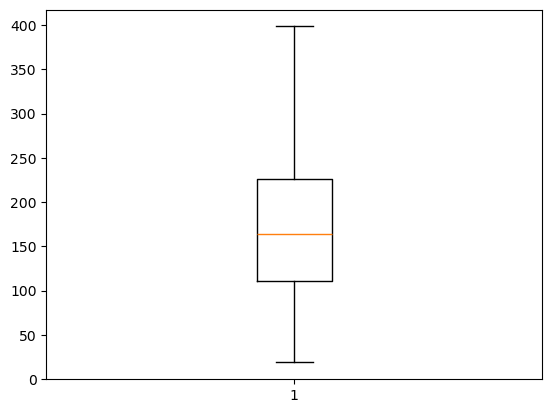

In [153]:
plt.boxplot(df['index_nsa']) 
plt.show()

In [154]:
descrete_categorical=['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name','place_id']
Contineous=['index_nsa','index_sa']
descrete_count=['yr','period']

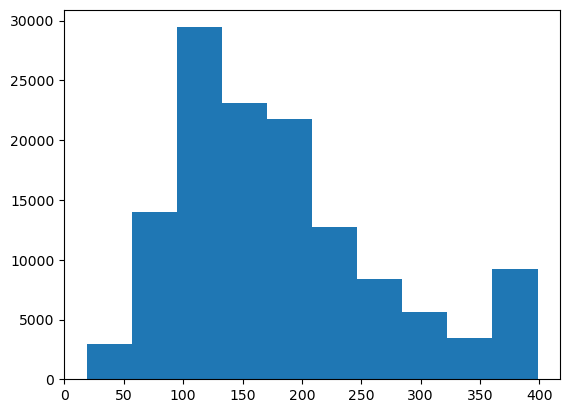

In [155]:
plt.hist(df['index_nsa'])
plt.show()

# Step5:Data Preprocessing

In [164]:
df['index_sa'].isnull().sum()/130696*100      

np.float64(66.7717451184428)

- 66% of the data is missing
- So now we drop the index_sa feature from the dataset

In [165]:
df=df.drop('index_sa',axis=1)
df.head()
df=df.drop('place_id',axis=1)
df.head()

,hpi_type,hpi_flavor,frequency,level,place_name,yr,period,index_nsa
0,4.0,2.0,0.0,3.0,113.0,1991,1,100.00
1,4.0,2.0,0.0,3.0,113.0,1991,2,100.87
2,4.0,2.0,0.0,3.0,113.0,1991,3,101.32
3,4.0,2.0,0.0,3.0,113.0,1991,4,101.73
4,4.0,2.0,0.0,3.0,113.0,1991,5,102.32


- 'place_id' feature not use for any analysis and prediction

In [166]:
df.isnull().sum()

hpi_type      0
hpi_flavor    0
frequency     0
level         0
place_name    0
yr            0
period        0
index_nsa     0
dtype: int64

- index_nsa has some outliers but retrain them

In [167]:
df['index_nsa'].skew()

np.float64(0.8908177277652044)

-  2.03 Skewness is normal(skewness range is -3 to +3)

# Step6: Data Wrangling

- Feature Encoding

In [168]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df["hpi_type"]=oe.fit_transform(df[['hpi_type']])
df["hpi_flavor"]=oe.fit_transform(df[['hpi_flavor']])
df["frequency"]=oe.fit_transform(df[['frequency']])
df["level"]=oe.fit_transform(df[['level']])
df["place_name"]=oe.fit_transform(df[['place_name']])
df.head()

,hpi_type,hpi_flavor,frequency,level,place_name,yr,period,index_nsa
0,4.0,2.0,0.0,3.0,113.0,1991,1,100.00
1,4.0,2.0,0.0,3.0,113.0,1991,2,100.87
2,4.0,2.0,0.0,3.0,113.0,1991,3,101.32
3,4.0,2.0,0.0,3.0,113.0,1991,4,101.73
4,4.0,2.0,0.0,3.0,113.0,1991,5,102.32


- Now The Data is Encoded to Numeric

# X and y

In [206]:
X=df.drop('index_nsa',axis=1)
y=df['index_nsa']

,hpi_type,hpi_flavor,frequency,level,place_name,yr,period
0,4.0,2.0,0.0,3.0,113.0,1991,1
1,4.0,2.0,0.0,3.0,113.0,1991,2


# Train Test Split

In [182]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

# Step7: Model Building

In [183]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

# Prediction

In [184]:
ytrain_predict=model.predict(X_train)
ytrain_predict

array([265.61813306, 118.8207574 , 136.0469476 , ..., 256.78417968,
        99.67016107,  94.49782536])

In [185]:
ytest_predict=model.predict(X_test)
ytest_predict

array([260.35994559, 194.80190578, 178.65473232, ..., 259.05382959,
       165.05454984, 111.64774774])

# Model Evaluation

# Cross validation score and RMSE

In [186]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
print("RMSE for train data:",mean_squared_error(y_train,ytrain_predict))
print("R2 score for train data:",r2_score(y_train,ytrain_predict))
print("cross val score for train data:",cross_val_score(model,X_train,y_train,cv=5).mean())

RMSE for train data: 2529.817808254202
R2 score for train data: 0.6820131108102132
cross val score for train data: 0.681956304896635


In [187]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
print("RMSE for test data:",mean_squared_error(y_test,ytest_predict))
print("R2 score for test data:",r2_score(y_test,ytest_predict))
print("cross val score for test data:",cross_val_score(model,X_test,y_test,cv=5).mean())

RMSE for test data: 2568.8466498881367
R2 score for test data: 0.6848517033503421
cross val score for test data: 0.6848308409203767


# Polynomial regression

In [188]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=5,include_bias=False)
polynomial_converter.fit_transform(X_train)

array([[4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        3.26755280e+07, 3.23360000e+04, 3.20000000e+01],
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        2.54977024e+08, 5.10976000e+05, 1.02400000e+03],
       [4.00000000e+00, 2.00000000e+00, 1.00000000e+00, ...,
        3.99200400e+06, 1.99800000e+03, 1.00000000e+00],
       ...,
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        4.08040000e+06, 2.02000000e+03, 1.00000000e+00],
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        3.97204900e+06, 1.99300000e+03, 1.00000000e+00],
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        2.53701184e+08, 5.09696000e+05, 1.02400000e+03]])

In [189]:
import pandas as pd
X_train_poly=pd.DataFrame(polynomial_converter.fit_transform(X_train))

In [190]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(X_train_poly,y_train)

LinearRegression()

In [191]:
print("Intercept:",model.intercept_)
print("coeficents:",model.coef_)

Intercept: -11589.287602234026
coeficents: [7.74887055e+00 2.28101557e+00 4.73271509e+01 1.83123565e+01
 1.40559538e-02 5.82320245e+00 1.33809243e+00]


In [193]:
ypred_train=model1.predict(X_train_poly)

In [194]:
from sklearn.metrics import r2_score
print("The r2 score of X_train",r2_score(y_train,ypred_train))
print("The cross val score:",cross_val_score(model,X_train_poly,y_train,cv=5).mean())

The r2 score of X_train 0.7899207598905029
The cross val score: 0.7893757666020109


In [116]:
X_test_poly=pd.DataFrame(polynomial_converter.transform(X_test))
ypred_test=model.predict(X_test_poly)

In [117]:
from sklearn.metrics import r2_score
print("The r2 score of X_test",r2_score(y_test,ypred_test))
print("The cross val score:",cross_val_score(model,X_test_poly,y_test,cv=5).mean())

The r2 score of X_test 0.7917307180529947
The cross val score: 0.7920971164228243


# Model Selection

In [86]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(df,test_size=0.2,random_state=0)

In [119]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
X = df_train.drop(columns=['index_nsa'])
X = X.assign(constant=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
print(vif_data)

      Feature           VIF
0    hpi_type      1.034162
1  hpi_flavor      1.191040
2   frequency      1.583104
3       level      1.262022
4  place_name      1.029182
5          yr      1.029694
6      period      1.304769
7    constant  28279.599926


- All predictors (hpi_type, hpi_flavor, frequency, level, place_name, yr, period) have VIF < 2
- This means no multicollinearity problem among your predictors.
- The only very high VIF is the constant, but that is normal and safe (we always ignore VIF for the intercept).

In [122]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

X = df.drop(columns=['index_nsa'])
y = df['index_nsa']

ridge = Ridge(alpha=1.0).fit(X, y)
print("R² Ridge:", r2_score(y, ridge.predict(X)))

lasso = Lasso(alpha=0.01).fit(X, y)
print("R² Lasso:", r2_score(y, lasso.predict(X)))


R² Ridge: 0.6826126244164865
R² Lasso: 0.6826116514121767


# Final Model

- Polynomoal Regression

# Step8: Save the Model

In [195]:
import pickle
pickle.dump(oe, open("ordinal_encoder.pkl", "wb"))
pickle.dump(polynomial_converter, open("poly.pkl", "wb"))
pickle.dump(model1, open("model.pkl", "wb"))

# Step9: predict future data

In [219]:
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[categorical_cols] = oe.fit_transform(df[categorical_cols])

In [221]:
sample_record = {
    "hpi_type": "traditional",
    "hpi_flavor": "purchase-only",
    "frequency": "monthly",
    "level": "USA or Census Division",
    "place_name": "New York",
    "yr": 2025,
    "period": 6
}
df_sample = pd.DataFrame([sample_record])
df_sample[categorical_cols] = oe.transform(df_sample[categorical_cols])
df_sample_poly = polynomial_converter.transform(df_sample)
y_pred = model1.predict(df_sample_poly)
print("Predicted HPI Index (NSA):", y_pred[0])

Predicted HPI Index (NSA): 12693.335988882556


In [222]:
sample_record1 = {
    "hpi_type": "expanded",                 
    "hpi_flavor": "all-transactions",        
    "frequency": "quarterly",              
    "level": "State",                      
    "place_name": "California",              
    "yr": 2024,                           
    "period": 3                             
}
df_sample = pd.DataFrame([sample_record1])
df_sample[categorical_cols] = oe.transform(df_sample[categorical_cols])
df_sample_poly = polynomial_converter.transform(df_sample)
y_pred = model1.predict(df_sample_poly)
print("Predicted HPI Index (NSA):", y_pred[0])

Predicted HPI Index (NSA): 12736.437332901132


In [223]:
sample_record2 = {
    "hpi_type": "expanded",
    "hpi_flavor": "all-transactions",
    "frequency": "annual",
    "level": "Metropolitan Statistical Area",
    "place_name": "Texas",
    "yr": 2023,
    "period": 1
}
df_sample = pd.DataFrame([sample_record2])
df_sample[categorical_cols] = oe.transform(df_sample[categorical_cols])
df_sample_poly = polynomial_converter.transform(df_sample)
y_pred = model1.predict(df_sample_poly)
print("Predicted HPI Index (NSA):", y_pred[0])

Predicted HPI Index (NSA): 12793.936213493838


In [230]:
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
X = df[["hpi_type", "hpi_flavor", "frequency", "level", "place_name", "yr", "period"]]
y = df["index_nsa"]
pipeline = Pipeline([
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ("model", LinearRegression())
])
pipeline.fit(X, y)
with open("model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

pipeline    

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('model', LinearRegression())])